# How have strong El Niño winters changed U.S. snowfall, and what does that suggest for 2026–27?

A strong El Niño was building through the summer of 2026, and "super El Niño"
has been the phrase in the news. This study asks what past strong El Niño
winters did to snowfall across the United States, region by region, using the
longest and most complete station records NOAA keeps, and classifying winters
by the index NOAA now uses officially.

It describes tendencies, not a forecast. Only eight winters since 1949 reached
the strong threshold on the official index, so every regional figure rests on
eight seasons, and a single winter can land anywhere. The study needs
`usdata[pandas]` and matplotlib, downloads about 200 MB, and runs in about a
minute.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-29T03:50:48+00:00
usdata 0.32.0; pandas 3.0.6


## Data

One manifest names nine sources:

- [GSOM station files](https://usdata.dev/datasets/noaa/gsom-station-files/),
  seven sources named by region, each the whole monthly record of its
  stations. The stations are every U.S. Historical Climatology Network (USHCN)
  station whose GHCN-Daily snowfall record runs from 1950 or earlier to 2025 or
  later, in seven regional boxes across the northern tier and the South.
  USHCN stations are the ones NOAA chose for long, stable,
  complete records, so no station was picked by its snowfall. The rule was
  applied to NCEI's `ghcnd-stations.txt` and `ghcnd-inventory.txt` of
  24 September 2026; the boxes are listed below.
- [CPC ENSO indices](https://usdata.dev/datasets/noaa/enso-indices/), `roni`
  and `oni`: the Relative Oceanic Niño Index, NOAA's official ENSO index since
  February 2026, and the traditional Oceanic Niño Index.

In [2]:
REGIONS = {  # west, south, east, north in degrees; each box is half-open
    "pacific-northwest": (-125.0, 42.0, -116.5, 49.0),
    "northern-rockies": (-116.5, 43.0, -104.0, 49.0),
    "upper-midwest": (-97.5, 43.5, -87.0, 49.0),
    "great-lakes-ohio-valley": (-89.0, 38.0, -78.0, 43.5),
    "northeast": (-78.0, 36.5, -67.0, 47.5),
    "southern-plains": (-104.0, 32.0, -94.0, 37.0),
    "southwest": (-114.0, 31.3, -104.0, 37.0),
}
result = pull(manifest)
for region in REGIONS:
    items = result.by_source[region]
    size = sum(item.provenance.size for item in items)
    print(f"{region:24} {len(items):3} stations  {size / 1e6:5.1f} MB")
print("Retrieved (UTC):", result.one("roni").provenance.retrieved_at.isoformat(timespec="seconds"))

pacific-northwest         44 stations   28.9 MB
northern-rockies          40 stations   25.0 MB
upper-midwest             40 stations   27.4 MB
great-lakes-ohio-valley   74 stations   49.8 MB
northeast                 70 stations   45.1 MB
southern-plains           28 stations   18.5 MB
southwest                 19 stations   12.1 MB
Retrieved (UTC): 2026-09-29T03:47:50+00:00


## Classifying winters

A winter here is November to March, named by the year it starts, from
1949-50 to 2025-26. Its strength is the peak of the three-month index over
OND, NDJ, and DJF, the seasons when El Niño usually peaks, and a strong El Niño
winter is one whose peak reaches +1.5 °C. That threshold is a convention for
"strong", not a CPC definition.

In [3]:
FIRST, LAST, STRONG = 1949, 2025, 1.5


def winter_peaks(name: str) -> pd.Series:
    """The peak OND, NDJ, or DJF value of one CPC index, per winter."""
    table = pd.read_csv(result.one(name).path, sep=r"\s+")
    table = table[table["SEAS"].isin(["OND", "NDJ", "DJF"])]
    winter = table["YR"] - (table["SEAS"] == "DJF")
    return table["ANOM"].groupby(winter).max().loc[FIRST:LAST]


peaks = pd.DataFrame({"RONI": winter_peaks("roni"), "ONI": winter_peaks("oni")})
strong = {name: sorted(peaks.index[peaks[name] >= STRONG]) for name in peaks}
table = peaks.loc[sorted(set(strong["RONI"]) | set(strong["ONI"]))]
table.index = [f"{year}-{str(year + 1)[2:]}" for year in table.index]
table

,RONI,ONI
1957-58,1.89,1.69
1965-66,1.99,1.82
1972-73,1.97,1.84
1982-83,2.40,2.14
1991-92,2.12,1.54
1997-98,2.28,2.37
2009-10,1.50,1.50
2015-16,2.25,2.59
2023-24,1.42,1.99


The two indices agree on eight strong winters. The traditional ONI adds
2023-24, which RONI reads as 1.42: it measures Niño 3.4 against the rest of the
tropics, which were unusually warm that winter. The composites below use
RONI.

## Winter snowfall

GSOM leaves a month blank when more than five of its days are missing or
flagged, so a winter counts at a station only when all five months have a
value. A station stays in the study with at least 60 complete winters of the
77, at least six of the eight strong ones, and a median winter of at least
10 cm, below which a ratio of snowfall means little.

In [4]:
frames = []
for region in REGIONS:
    for item in result.by_source[region]:
        frame = pd.read_csv(
            item.path,
            usecols=["STATION", "DATE", "LATITUDE", "LONGITUDE", "ELEVATION", "SNOW"],
            dtype={"STATION": "string"},
        )
        frames.append(frame.assign(region=region))
monthly = pd.concat(frames, ignore_index=True)
month = monthly["DATE"].str[5:].astype(int)
monthly = monthly[month.isin([11, 12, 1, 2, 3])].copy()
monthly["winter"] = monthly["DATE"].str[:4].astype(int) - (monthly["DATE"].str[5:].astype(int) <= 3)
monthly = monthly[monthly["winter"].between(FIRST, LAST)]
stations = monthly.groupby("STATION")[["region", "LATITUDE", "LONGITUDE", "ELEVATION"]].first()

counts = monthly.groupby(["STATION", "winter"])["SNOW"].agg(["count", "sum"])
winters = counts["sum"].where(counts["count"] == 5).unstack("winter") / 10  # cm
complete = winters.notna().sum(axis=1)
complete_strong = winters[strong["RONI"]].notna().sum(axis=1)
usual = winters.median(axis=1)
keep = (complete >= 60) & (complete_strong >= 6) & (usual >= 10)
long_record = complete >= 60
enough_strong = long_record & (complete_strong >= 6)
print(f"{len(winters)} stations; kept {int(keep.sum())}")
print(f"  fewer than 60 complete winters: {int((~long_record).sum())}")
print(f"  fewer than 6 complete strong winters: {int((long_record & ~enough_strong).sum())}")
print(f"  median winter under 10 cm: {int((enough_strong & (usual < 10)).sum())}")
snow = winters[keep]
stations = stations.loc[snow.index]
stations.groupby("region").size().rename("stations").to_frame().T

315 stations; kept 158
  fewer than 60 complete winters: 133
  fewer than 6 complete strong winters: 11
  median winter under 10 cm: 13


region,great-lakes-ohio-valley,northeast,northern-rockies,pacific-northwest,southern-plains,southwest,upper-midwest
stations,46,43,11,17,8,6,27


## Strong El Niño winters against the usual

For each station, the ratio is its median snowfall in the strong El Niño
winters over its median in all winters: 0.5 is half its usual snow, 2 is
double. A region's figure is the median of its stations' ratios. To judge
whether a figure could be chance, the same calculation is repeated 2,000
times with eight winters drawn at random, and the share of draws at least as
far from 1 as the real one is reported as a two-sided p-value.

In [5]:
def ratios(table: pd.DataFrame, chosen) -> pd.Series:
    """Each station's median snowfall in the chosen winters over its median in all."""
    return table[list(chosen)].median(axis=1) / table.median(axis=1)


stations["ratio"] = ratios(snow, strong["RONI"])
regions = stations.groupby("region")["ratio"].agg(
    stations="size", median_ratio="median", share_below=lambda r: (r < 1).mean()
)
rng = np.random.default_rng(1950)
draws = np.array(
    [
        ratios(snow, rng.choice(snow.columns, size=len(strong["RONI"]), replace=False))
        .groupby(stations["region"])
        .median()
        .reindex(regions.index)
        for _ in range(2000)
    ]
)
distance = np.abs(np.log(regions["median_ratio"].to_numpy()))
regions["p"] = (np.abs(np.log(draws)) >= distance).mean(axis=0)
by_winter = (
    snow[strong["RONI"]].div(snow.median(axis=1), axis=0).groupby(stations["region"]).median()
)
regions["strong_winters_below"] = (by_winter < 1).sum(axis=1).astype(int)
regions = regions.loc[list(REGIONS)]
regions.round(2)

,stations,median_ratio,share_below,p,strong_winters_below
region,,,,,
pacific-northwest,17,0.57,0.94,0.00,7
northern-rockies,11,0.80,1.00,0.02,8
upper-midwest,27,0.83,0.96,0.11,6
great-lakes-ohio-valley,46,0.78,0.85,0.03,7
northeast,43,0.92,0.74,0.45,5
southern-plains,8,1.84,0.00,0.05,2
southwest,6,1.39,0.00,0.07,2


## A first look

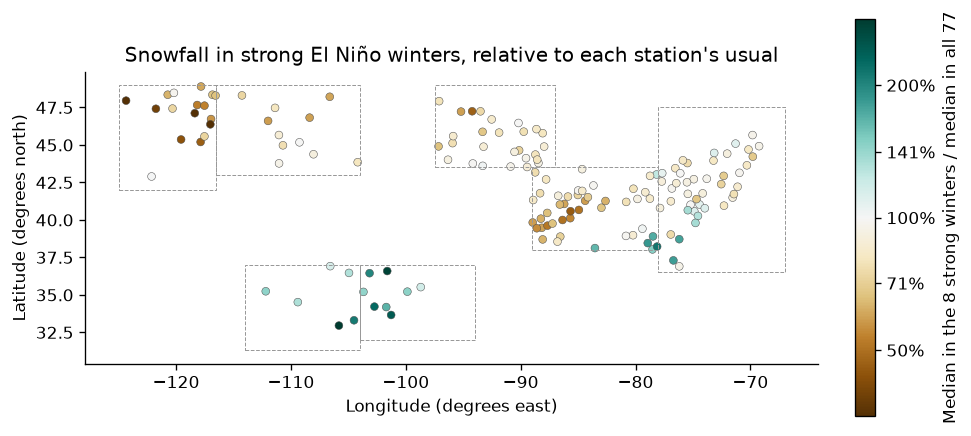

In [6]:
fig, ax = plt.subplots(layout="constrained")
mesh = ax.scatter(
    stations["LONGITUDE"],
    stations["LATITUDE"],
    c=np.log2(stations["ratio"]),
    cmap="BrBG",
    vmin=-1.5,
    vmax=1.5,
    s=22,
    edgecolor="0.3",
    linewidth=0.3,
)
for west, south, east, north in REGIONS.values():
    ax.add_patch(
        plt.Rectangle(
            (west, south),
            east - west,
            north - south,
            fill=False,
            edgecolor="0.6",
            linewidth=0.6,
            linestyle="--",
        )
    )
ax.set_aspect(1 / np.cos(np.radians(40)))
ax.grid(False)
ax.set_xlabel("Longitude (degrees east)")
ax.set_ylabel("Latitude (degrees north)")
ax.set_title("Snowfall in strong El Niño winters, relative to each station's usual")
bar = fig.colorbar(mesh, ax=ax, shrink=0.75, ticks=np.log2([0.35, 0.5, 0.71, 1, 1.41, 2, 2.83]))
bar.ax.set_yticklabels(["35%", "50%", "71%", "100%", "141%", "200%", "283%"])
bar.set_label("Median in the 8 strong winters / median in all 77")
plt.show()

The pattern is the one the atmosphere's response to El Niño predicts: the
Pacific jet stream shifts south, so the Pacific Northwest and northern Rockies
get less snow and the southern tier more. In the eight strong winters, the
median Pacific Northwest station got a little over half its usual snowfall,
and 85 to 100 percent of the stations in each of the four northern interior
regions got less than usual. Random draws of eight winters rarely do as well
there (p of 0.03 or less), except in the Upper Midwest (0.11). The southern
Plains and the Southwest got more, though from only 8 and 6 stations. The
Northeast, where coastal storms can go either way, shows no clear shift.

## When the indices disagree: 2023-24

The one winter the two indices classify differently is 2023-24: strong on the
traditional ONI (1.99), not on RONI (1.42). Its snowfall is shown against each
region's strong-winter median.

In [7]:
last_winter = (snow[2023] / snow.median(axis=1)).groupby(stations["region"]).median()
comparison = pd.DataFrame(
    {
        "strong El Niño winters": regions["median_ratio"],
        "2023-24": last_winter.reindex(regions.index),
    }
)
comparison.round(2)

,strong El Niño winters,2023-24
region,,
pacific-northwest,0.57,0.71
northern-rockies,0.80,0.82
upper-midwest,0.83,0.52
great-lakes-ohio-valley,0.78,0.47
northeast,0.92,0.53
southern-plains,1.84,0.70
southwest,1.39,0.96


2023-24 was a low-snow winter nearly everywhere in the north, well below
even the strong-winter composite in the Great Lakes, Upper Midwest, and
Northeast, and it did not bring the southern tier its usual strong-El Niño
boost. Counting it, as the traditional index would, weakens the southern
figures, from 1.84 to 1.67 in the southern Plains and from 1.39 to 1.27 in the
Southwest, and moves the northern ones by 0.01 to 0.06.

In [8]:
with_2023 = stations.assign(ratio_oni=ratios(snow, strong["ONI"]))
with_2023.groupby("region")[["ratio", "ratio_oni"]].median().loc[list(REGIONS)].round(2)

,ratio,ratio_oni
region,,
pacific-northwest,0.57,0.63
northern-rockies,0.80,0.81
upper-midwest,0.83,0.78
great-lakes-ohio-valley,0.78,0.75
northeast,0.92,0.87
southern-plains,1.84,1.67
southwest,1.39,1.27


## What this suggests for 2026-27

CPC's latest season in these tables is JJA 2026: RONI +1.36 and ONI +1.80.
Whether the winter reaches the strong threshold on the official index depends
on how the event develops through the autumn, which these tables cannot say.

In [9]:
roni = pd.read_csv(result.one("roni").path, sep=r"\s+")
oni = pd.read_csv(result.one("oni").path, sep=r"\s+")
latest = roni.iloc[-1]
print(
    f"Latest season: {latest['SEAS']} {latest['YR']}: RONI {latest['ANOM']:+.2f}, "
    f"ONI {oni.iloc[-1]['ANOM']:+.2f}"
)
print("\nIf 2026-27 is a strong El Niño winter, the eight past ones suggest:")
for region, row in regions.iterrows():
    print(
        f"  {region:24} median {row['median_ratio']:.0%} of usual; "
        f"{int(row['strong_winters_below'])} of 8 strong winters below usual"
    )

Latest season: JJA 2026: RONI +1.36, ONI +1.80

If 2026-27 is a strong El Niño winter, the eight past ones suggest:
  pacific-northwest        median 57% of usual; 7 of 8 strong winters below usual
  northern-rockies         median 80% of usual; 8 of 8 strong winters below usual
  upper-midwest            median 83% of usual; 6 of 8 strong winters below usual
  great-lakes-ohio-valley  median 78% of usual; 7 of 8 strong winters below usual
  northeast                median 92% of usual; 5 of 8 strong winters below usual
  southern-plains          median 184% of usual; 2 of 8 strong winters below usual
  southwest                median 139% of usual; 2 of 8 strong winters below usual


If 2026-27 is a strong winter, the past eight point to less snow than usual
across the northern tier, most of all in the Pacific Northwest, and more in
the southern Plains and Southwest. They do not say how much any one place
will get: even where the tendency is strongest, individual winters vary, and
eight is a small sample. NOAA's own winter outlook, which combines ENSO with
other signals and models, is the forecast to read.

## Pin and cite

`verify` checks every cached file against the lockfile's checksums. NCEI
rewrites station files weekly and CPC rewrites its tables monthly, so this
study's lockfile is committed and restored weekly, and its bytes are kept on
the mirror. The citations below are what a methods section needs, and
`usdata cite dataset.yaml` prints the same.

In [10]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:gsom-station-files
  Lawrimore, Jay H.; Ray, Ron; Applequist, Scott; Korzeniewski, Bryant; Menne, Matthew J. (2016): Global Summary of the Month (GSOM), Version 1. NOAA National Centers for Environmental Information. https://doi.org/10.7289/V5QV3JJ5
  homepage: https://www.ncei.noaa.gov/data/global-summary-of-the-month/
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00946/html
  retrieved: 2026-09-29; 315 checksummed assets (206,687,304 bytes) pinned by usdata 0.32.0
  sources: pacific-northwest, northern-rockies, upper-midwest, great-lakes-ohio-valley, northeast, southern-plains, southwest
noaa:enso-indices
  NOAA Climate Prediction Center, Relative Oceanic Niño Index and Oceanic Niño Index, accessed via usdata
  homepage: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/roni/
  license: US Government Work (public domain)
  terms: https://www.weather.gov/disclaimer
  retrieved: 2

## What was awkward

- Choosing stations needed NCEI's station list and inventory, which are not in
  the catalog, so the station rule was applied outside this notebook and only
  its result, the manifest, is pinned.
- The Access Data Service could not deliver 77 years at 315 stations: its
  requests stalled for minutes. The study uses whole station files instead, at
  about 200 MB for one element's worth of analysis.
- GSOM blanks a month with more than five missing days, and many cooperative
  stations have gaps: 157 of the 315 fell short of the completeness rule.
- The two ENSO indices disagree on 2023-24, and news about a "super El Niño"
  rarely says which index it means.
- Region boxes are rectangles in latitude and longitude, not climate
  divisions, and the southern boxes hold few stations with enough snow.